In [1]:
# === Notebook common preamble (load the llm_math package) ===
import sys
from pathlib import Path

# Candidate paths for the llm_math package
_candidates = [
    '.', 'src', '..', '../src',
    '/content/llm-math-book/src',
    '/content/llm-math-book',
    '/workspace/src',
    '/workspace',
]
# Add parent directories as candidates (when running from the notebooks folder)
for p in Path.cwd().parents:
    _candidates.append(str(p / 'src'))
    _candidates.append(str(p))

for p in _candidates:
    if p and p not in sys.path and Path(p).exists():
        sys.path.insert(0, p)

# Try importing llm_math
try:
    from llm_math import viz, bench, data
    _LLM_MATH_OK = True
except ImportError as e:
    _LLM_MATH_OK = False
    print(f"[Warning] load the llm_math package text: {e}")
    print("  Clone the GitHub repository and run colab_setup.sh.")
# === end preamble ===


# Ch 03. Calculus and Optimization text — text text

> **Learning Goals**
> - text "text text"text "text text"text text text
> - text text $\nabla f$text text text text text
> - text text text text

## 3.1 text text

text $f'(x)$text Function $f$text **text text**text.

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

text text $(x, f(x))$text **text text**.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Numerical Differentiation text
def numerical_diff(f, x, h=1e-5):
    """text text (central difference)text text Differential."""
    return (f(x + h) - f(x - h)) / (2 * h)

# text Function
def f(x):
    return x**2

def f_prime(x):
    return 2 * x  # Analytic Differential

# Comparison
x0 = 3.0
print(f"f(x) = x^2, x = {x0}")
print(f"Analytic Differential f'(x) = 2x = {f_prime(x0)}")
print(f"text Differential (h=1e-5): {numerical_diff(f, x0):.6f}")
print(f"Error: {abs(numerical_diff(f, x0) - f_prime(x0)):.2e}")


f(x) = x^2, x = 3.0
Analytic Differential f'(x) = 2x = 6.0
text Differential (h=1e-5): 6.000000
Error: 3.93e-11


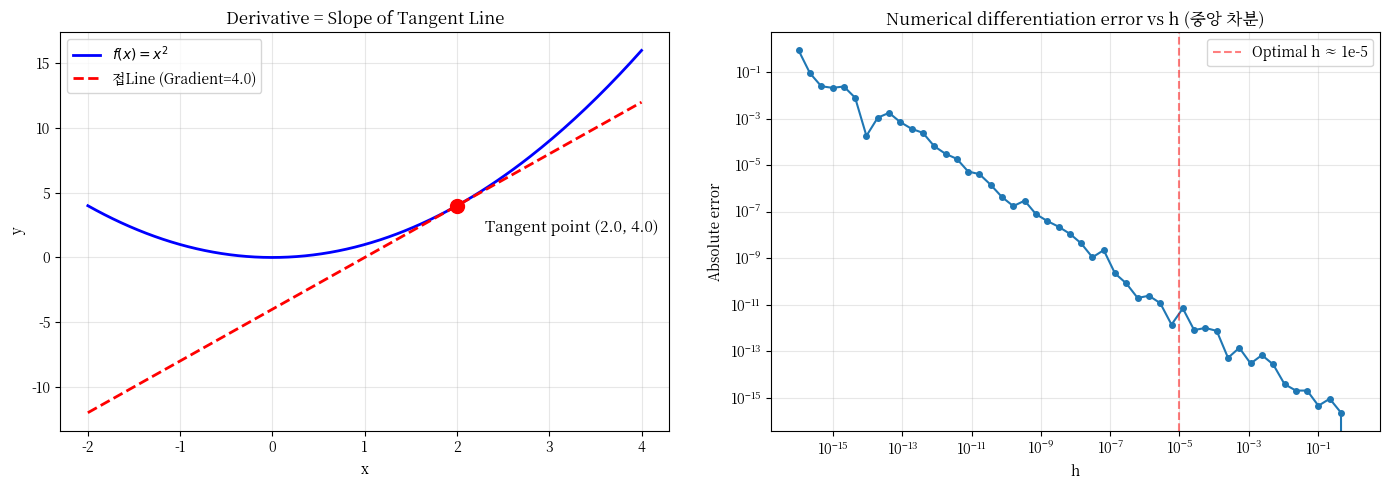

In [3]:
# text text text Visualization
def f(x): return x**2

x = np.linspace(-2, 4, 200)
y = f(x)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Functiontext text
ax = axes[0]
ax.plot(x, y, 'b-', linewidth=2, label='$f(x) = x^2$')
x0 = 2.0
y0 = f(x0)
slope = 2 * x0
tangent = slope * (x - x0) + y0
ax.plot(x, tangent, 'r--', linewidth=2, label=f'textLine (Gradient={slope:.1f})')
ax.plot(x0, y0, 'ro', markersize=10)
ax.annotate(f'Tangent point ({x0}, {y0})', xy=(x0, y0), xytext=(x0+0.3, y0-2),
            fontsize=11)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Derivative = Slope of Tangent Line')
ax.legend(); ax.grid(True, alpha=0.3)

# htext text Numerical Differentiation Error
ax = axes[1]
hs = np.logspace(-16, 0, 50)
errors = [abs(numerical_diff(f, 1.0, h=h) - 2.0) for h in hs]
ax.loglog(hs, errors, 'o-', markersize=4)
ax.set_xlabel('h')
ax.set_ylabel('Absolute error')
ax.set_title('Numerical differentiation error vs h (text text)')
ax.grid(True, alpha=0.3, which='both')
# htext text textPlane textPoint Error, text textPlane text Error
ax.axvline(1e-5, color='r', linestyle='--', alpha=0.5, label='Optimal h ≈ 1e-5')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/ch03_derivative.png', dpi=100, bbox_inches='tight')
plt.show()
print("Warning: htext text textPlane textPoint Errortext, text textPlane text Errortext text.")


## 3.2 text text text text

| Function | Derivative |
|---|---|
| $x^n$ | $nx^{n-1}$ |
| $e^x$ | $e^x$ |
| $\ln x$ | $1/x$ |
| $\sin x$ | $\cos x$ |
| $\sigma(x) = \frac{1}{1+e^{-x}}$ | $\sigma(x)(1-\sigma(x))$ |

**text text (Chain Rule)**: textFunctiontext text

$$\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$$

text Backpropagationtext text text! (Ch 07text text)


In [4]:
# text text text Verification
def f(g): return g**2          # f(g) = g^2
def g(x): return np.sin(x)    # g(x) = sin(x)
# text: f(g(x)) = sin(x)^2

# Numerical Differentiation (text Function text)
def compose(x): return f(g(x))
df_dx_numerical = numerical_diff(compose, 1.0)

# Analytic (text text): f'(g(x)) * g'(x) = 2*sin(x) * cos(x)
x0 = 1.0
df_dx_chain = 2 * np.sin(x0) * np.cos(x0)

print(f"f(g(x)) = sin(x)^2, x = {x0}")
print(f"text Differential: {df_dx_numerical:.6f}")
print(f"text text: 2*sin(x)*cos(x) = {df_dx_chain:.6f}")
print(f"Error: {abs(df_dx_numerical - df_dx_chain):.2e}")


f(g(x)) = sin(x)^2, x = 1.0
text Differential: 0.909297
text text: 2*sin(x)*cos(x) = 0.909297
Error: 6.02e-11


## 3.3 text Functiontext text

$f(x, y)$text text $\frac{\partial f}{\partial x}$text $y$text text text $x$text text.

**text**text text text text Vector:
$$\nabla f(\mathbf{x}) = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right]^\top$$

text Functiontext **text text text Direction**text text. text text **text Direction** $-\nabla f$text text.


f(x, y) = x^2 + 3y^2, (x, y) = (1.5, 1.0)
Analytic Gradient: [3. 6.]
text Gradient:   [3. 6.]


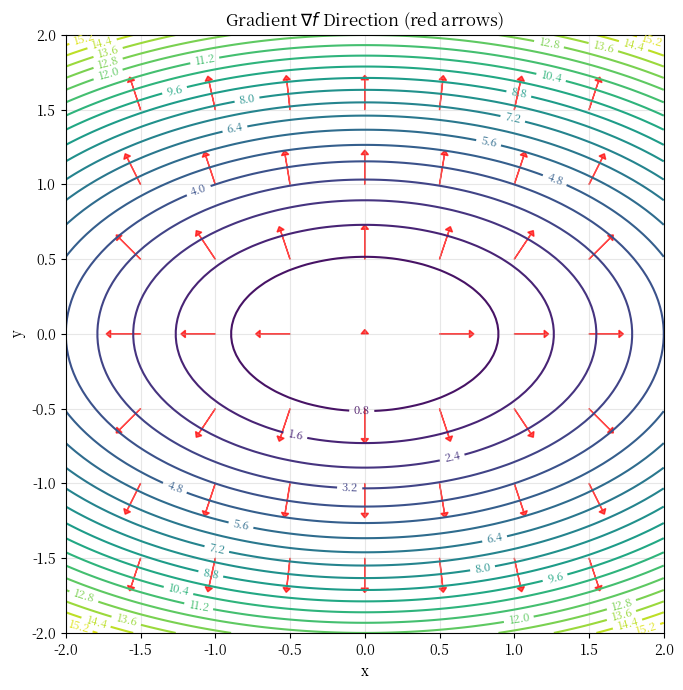

=> Gradienttext text textLinetext text, text text text Directiontext.


In [5]:
# text Functiontext text
def f_2d(x, y):
    return x**2 + 3*y**2  # text text

def grad_f_2d(x, y):
    return np.array([2*x, 6*y])  # [df/dx, df/dy]

# text text
def numerical_grad_2d(f, x, y, h=1e-5):
    dfdx = (f(x+h, y) - f(x-h, y)) / (2*h)
    dfdy = (f(x, y+h) - f(x, y-h)) / (2*h)
    return np.array([dfdx, dfdy])

x0, y0 = 1.5, 1.0
print(f"f(x, y) = x^2 + 3y^2, (x, y) = ({x0}, {y0})")
print(f"Analytic Gradient: {grad_f_2d(x0, y0)}")
print(f"text Gradient:   {numerical_grad_2d(f_2d, x0, y0)}")

# text text Direction Visualization
fig, ax = plt.subplots(figsize=(8, 7))
xs = np.linspace(-2, 2, 100)
ys = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(xs, ys)
Z = X**2 + 3*Y**2
cs = ax.contour(X, Y, Z, levels=20, cmap='viridis')
ax.clabel(cs, inline=True, fontsize=8)

# text Pointtext Gradient Arrow
for xi in np.linspace(-1.5, 1.5, 7):
    for yi in np.linspace(-1.5, 1.5, 7):
        g = grad_f_2d(xi, yi)
        # Normalizationtext Directiontext Display
        g_norm = g / (np.linalg.norm(g) + 1e-8) * 0.2
        ax.arrow(xi, yi, g_norm[0], g_norm[1], head_width=0.05,
                 head_length=0.03, fc='red', ec='red', alpha=0.7)

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Gradient $\\nabla f$ Direction (red arrows)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ch03_gradient_field.png', dpi=100, bbox_inches='tight')
plt.show()
print("=> Gradienttext text textLinetext text, text text text Directiontext.")


## 3.4 text (Gradient Descent)

text Problem: $\min_{\mathbf{x}} f(\mathbf{x})$

text text text:
$$\mathbf{x}_{t+1} = \mathbf{x}_t - \eta \, \nabla f(\mathbf{x}_t)$$

- $\eta$: Trainingtext(learning rate). text text text, text text text.
- text **text Direction**text text = text text text Direction


text: (1.800, 1.500)
50Step text: (0.000026, 0.000000)
MinimumValue f(0, 0) = 0, degreestextValue f = 6.60e-10


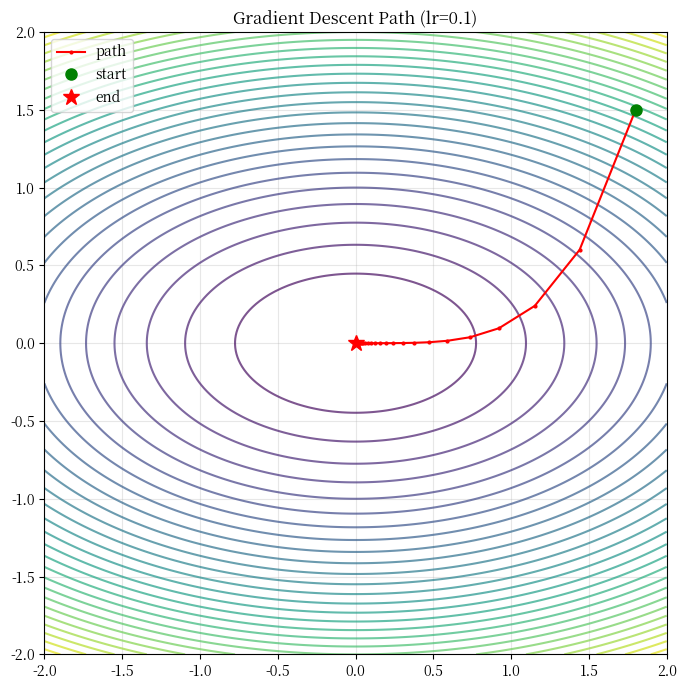

In [6]:
# text text
def gradient_descent_2d(f, grad_f, x0, y0, lr=0.1, n_steps=50):
    """2D Functiontext text text."""
    path = [(x0, y0)]
    x, y = x0, y0
    for _ in range(n_steps):
        gx, gy = grad_f(x, y)
        x = x - lr * gx
        y = y - lr * gy
        path.append((x, y))
    return np.array(path)

# f(x, y) = x^2 + 3y^2 (MinimumPoint: (0, 0))
path = gradient_descent_2d(f_2d, grad_f_2d, x0=1.8, y0=1.5, lr=0.1, n_steps=50)
print(f"text: ({path[0, 0]:.3f}, {path[0, 1]:.3f})")
print(f"50Step text: ({path[-1, 0]:.6f}, {path[-1, 1]:.6f})")
print(f"MinimumValue f(0, 0) = 0, degreestextValue f = {f_2d(path[-1, 0], path[-1, 1]):.2e}")

# Visualization
from llm_math.viz import plot_contour_and_path
fig, ax = plt.subplots(figsize=(8, 7))
plot_contour_and_path(
    ax, lambda v: f_2d(v[0], v[1]), path,
    xlim=(-2, 2), ylim=(-2, 2),
    title='Gradient Descent Path (lr=0.1)'
)
plt.tight_layout()
plt.savefig('../figures/ch03_gd_path.png', dpi=100, bbox_inches='tight')
plt.show()


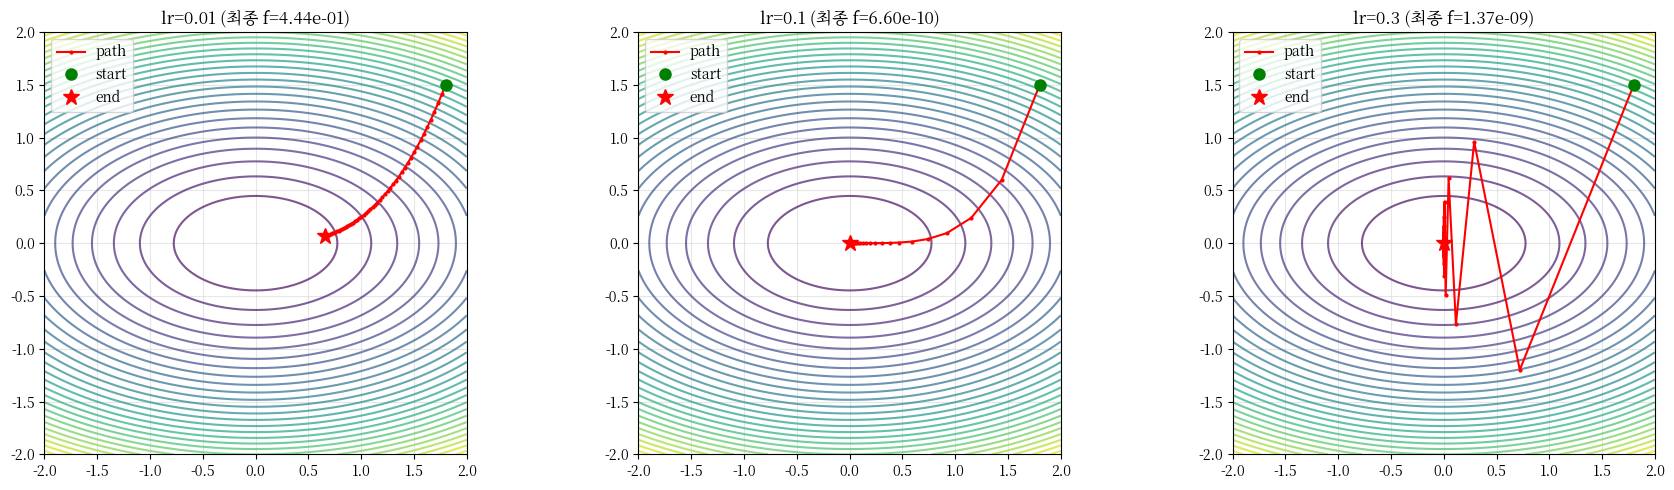

=> Learning Ratetext textPlane text, text textPlane Divergencetext text.


In [7]:
# Trainingtext text text Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, lr in zip(axes, [0.01, 0.1, 0.3]):
    path = gradient_descent_2d(f_2d, grad_f_2d, x0=1.8, y0=1.5, lr=lr, n_steps=50)
    plot_contour_and_path(
        ax, lambda v: f_2d(v[0], v[1]), path,
        xlim=(-2, 2), ylim=(-2, 2),
        title=f'lr={lr} (text f={f_2d(*path[-1]):.2e})'
    )
plt.tight_layout()
plt.savefig('../figures/ch03_lr_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("=> Learning Ratetext textPlane text, text textPlane Divergencetext text.")


## 3.5 text vs text text

**text(convex)** Function: text text text text text. text text text.
- text: $f(x) = x^2$, text text MSE text

**text(non-convex)** Function: text text text. text text Functiontext text text.
- text text text text text text
- text textDimensiontext text text text(saddle point)text text Problem


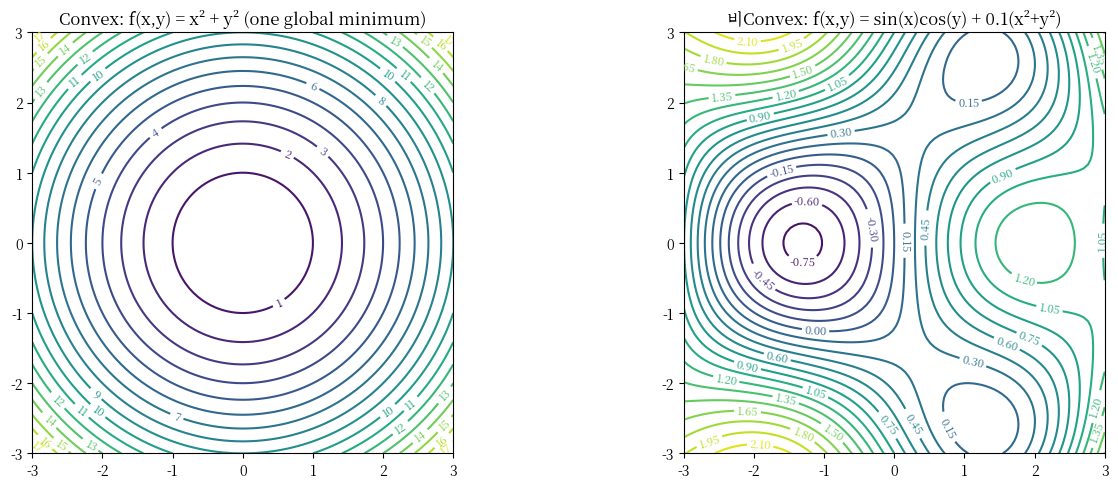

text Loss Functiontext text Dimensiontext textConvex Functiontext. text textdegrees text text!
text: textDimensiontext text Minimumtext textAdvantagetext textdegreestext text, textAdvantagetext text text.


In [8]:
# text vs text Function text
def convex_f(x, y): return x**2 + y**2
def nonconvex_f(x, y): return np.sin(x) * np.cos(y) + 0.1 * (x**2 + y**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
xs = np.linspace(-3, 3, 100)
ys = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(xs, ys)

# text
Z1 = convex_f(X, Y)
cs = axes[0].contour(X, Y, Z1, levels=20, cmap='viridis')
axes[0].clabel(cs, inline=True, fontsize=8)
axes[0].set_title('Convex: f(x,y) = x² + y² (one global minimum)')
axes[0].set_aspect('equal')

# textConvex
Z2 = nonconvex_f(X, Y)
cs = axes[1].contour(X, Y, Z2, levels=20, cmap='viridis')
axes[1].clabel(cs, inline=True, fontsize=8)
axes[1].set_title('textConvex: f(x,y) = sin(x)cos(y) + 0.1(x²+y²)')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('../figures/ch03_convex_nonconvex.png', dpi=100, bbox_inches='tight')
plt.show()
print("text Loss Functiontext text Dimensiontext textConvex Functiontext. text textdegrees text text!")
print("text: textDimensiontext text Minimumtext textAdvantagetext textdegreestext text, textAdvantagetext text text.")


## 3.6 Key Takeaways

| text | text | text |
|---|---|---|
| Derivative | $f'(x) = \lim_{h\to 0}\frac{f(x+h)-f(x)}{h}$ | text text |
| text text | $\frac{d}{dx}f(g(x)) = f'(g)g'(x)$ | textFunction text (Backpropagation text) |
| text | $\frac{\partial f}{\partial x_i}$ | text text text |
| text | $\nabla f = [\partial f/\partial x_i]$ | text text text Direction |
| text | $\mathbf{x} \leftarrow \mathbf{x} - \eta\nabla f$ | text text |

## Exercises

1. $f(x) = x^3 - 3x^2 + 2$text Derivativetext text, Numerical Differentiationtext Verificationtext.
2. $f(x, y) = x^2 y + \sin(xy)$text text $\nabla f$text Analytictext text text Verificationtext.
3. text $f(x, y) = (x-3)^2 + (y+2)^2$text text text. Trainingtext text text Speedtext Comparisontext.
4. Trainingtext text text text text text text text.
5. text(saddle point) text $f(x, y) = x^2 - y^2$text text, text text text text text text.

> Solutions: `solutions/ch03_solutions.ipynb`
